***
**Problem 1: Extending the lady tasting tea**


Let's extend the Lady Tasting Tea experiment as follows. The original experiment has 8 cups: 4 tea-first and 4 milk-first. Suppose we prepare 12 cups: 8 tea-first and 4 milk-first. A participant claims they can tell which was poured first.

Simulate this experiment using numpy by randomly shuffling the cups many times and calculating the probability of the participant correctly identifying all cups by chance. Compare your result with the original 8-cup experiment.

In your notebook, explain your simulation process clearly, report and interpret the estimated probability, and discuss whether, based on this probability, you would consider extending or relaxing the p-value threshold compared to the original design.

**Aim:** Estimate the probability that someone could correctly identify all milk-first cups by random guessing. 


*Null Hypothesis:*

The person testing the tea has no special ability to tell the difference between the cups of tea with milk in first and is selecting the four cups from the twelve randomly.

*Alternative Hypothesis:*

The person has some ability to identify the four cups with milk poured first and result is better than random chance. 

**Setup:**

-   find how many possible guesses the lady can make by chance

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import itertools

In [2]:
# Number of cups of tea in total. 
total_cups = 12

# Number of cups of tea with milk in first.
milk_first = 4

# Number of cups of tea with tea in first.
tea_first = 8

-   The lady must guess which four cups had milk poured 
first. 
-    The experiment defines which exact four cups had milk first. One combination exists of 4 cups with milk first. 
-   How many ways are there to choose four cups from twelve?

**Number of combinations:**

[math.comb(n,k)](https://docs.python.org/3/library/math.html#math.comb) counts the number of combinations



In [ ]:
# Total number of ways to choose cups with milk in first

math.comb(total_cups, milk_first)

495

-   There are 495 possible sets of 4 cups with milk first to choose from 12 cups when order does not matter.
-   Only one of those sets is the correct set. 

The probability that a random guess picks the one correct set: 

$Probability = 1/495$

In [4]:
1/495

0.00202020202020202

**Simulation:**

In [ ]:
# NumPy array:

cups = np.array([1]*milk_first + [0]*tea_first)
cups

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [17]:
# initialise counter to track number of successful guesses
success = 0 


In [18]:
# Number of simulations:
simulations = 1000000


*Run simulation:*

In [19]:
# for loop to randomly shuffle cups and make random guesses
for _ in range(simulations):
    np.random.shuffle(cups)
    guess = np.random.choice(total_cups, milk_first, replace=False)
    if np.all(cups[guess] == 1):
        success += 1

print("Simulated probability:", success / simulations)
print("Exact probability:", 1/495)


Simulated probability: 0.001949
Exact probability: 0.00202020202020202


-   simulates what would happen if the lady was guessing randomly
-   shuffles the cups and picks 4 randomly
-   count how often a perfect guess occurs --> p value
-   each run represents one guess
-   np.all(cups[guess]==1) checks if the guess is perfect. all 4 milk first cups. 
-   success counts the number of perfect guesses in all trials. 

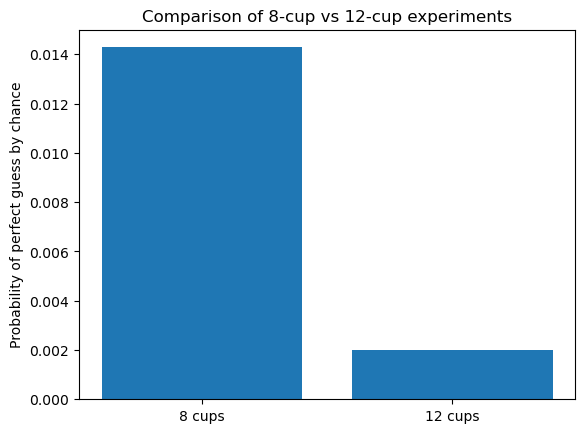

In [21]:
original_prob = 1/70      # 8 cups, 4 milk-first
extended_prob = 1/495     # 12 cups, 4 milk-first

plt.bar(["8 cups", "12 cups"], [original_prob, extended_prob])
plt.ylabel("Probability of perfect guess by chance")
plt.title("Comparison of 8-cup vs 12-cup experiments")
plt.show()


As the total number of cups increases, the number of possible 4 cup combinations increases. Therefore, the chance of randomly choosing the exact four milk first cups decrease and the probability decreases.

if the lady identified all four milk first cups correctly the p-value is 0.020. This is less than the significance value of a = 0.05, --> therefore she likely has a special ability to distinguish the tea. 

**Null Hypothesis(Ho):** The lady is guessing and has no special ability

**Alternative Hypothesis(H1):** The lady can correctly identify the milk-first cups better than chance 

significance level: a = 0.05
p value: 0.020

The p-value(0.020) is less than the significance value 0.05, therefore the null hypothesis is rejected. The result shows strong evidence that the lady has an ability to distinguish between the cups of tea. 



Both experiments reject the null hypothesis at the 0.05 significance level. However, the 12 cup experiment shows much stronger evidence that the lady is not choosing by random chance, with a p-value of 0.002 compared to 0.014 in the 8 cup experiment. If the significance level was reduced to 0.01 to reduce the risk of a type 1 error, the 12 cup result would still be significant but the 8 cup result would no longer meet the threshold and the null hypothesis would not be rejected for the 8 cup test which could lead to a type 2 error of not detecting an ability when one exists.  

***

**Problem 2: Normal Distribution:**

Generate 100,000 samples of size 10 from the standard normal distribution. For each sample, compute the standard deviation with ddof=1 (sample SD) and with ddof=0 (population SD). Plot histograms of both sets of values on the same axes with transparency. Describe the differences you see. Explain how you expect these differences to change if the sample size is increased.

https://numpy.org/doc/2.1/reference/random/generated/numpy.random.normal.html

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

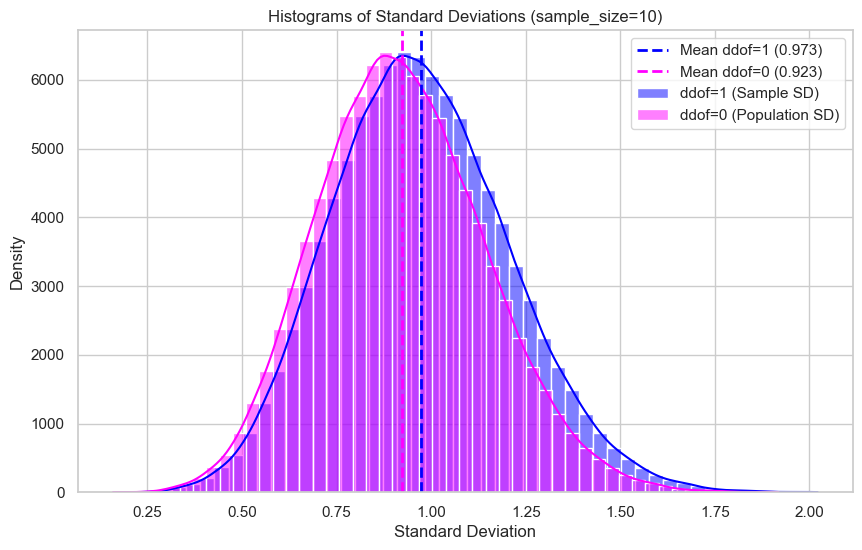

In [ ]:


number_samples = 100000
sample_size = 10

samples = np.random.normal(loc=0, scale=1, size=(number_samples, sample_size))

# Calculate standard deviations
std_ddof1 = np.std(samples, axis=1, ddof=1)  # Sample SD
std_ddof0 = np.std(samples, axis=1, ddof=0)  # Population SD

# Calculate means
mean_ddof1 = np.mean(std_ddof1)
mean_ddof0 = np.mean(std_ddof0)


sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot histograms with KDE
sns.histplot(std_ddof1, bins=50, color='blue', label='ddof=1 (Sample SD)', kde=True, alpha=0.5)
sns.histplot(std_ddof0, bins=50, color='magenta', label='ddof=0 (Population SD)', kde=True, alpha=0.5)

# Add mean lines  
plt.axvline(mean_ddof1, color='blue', linestyle='--', linewidth=2, label=f'Mean ddof=1 ({mean_ddof1:.3f})')
plt.axvline(mean_ddof0, color='magenta', linestyle='--', linewidth=2, label=f'Mean ddof=0 ({mean_ddof0:.3f})')

plt.xlabel('Standard Deviation')
plt.ylabel('Density')
plt.title('Histograms of Standard Deviations (sample_size=10)')
plt.legend()
plt.show()


For sample size 10, the sample standard deviation (ddof=1) appears to be larger and more skewed to the right, while the population standard deviation (ddof=0) is smaller and slightly skewed left.

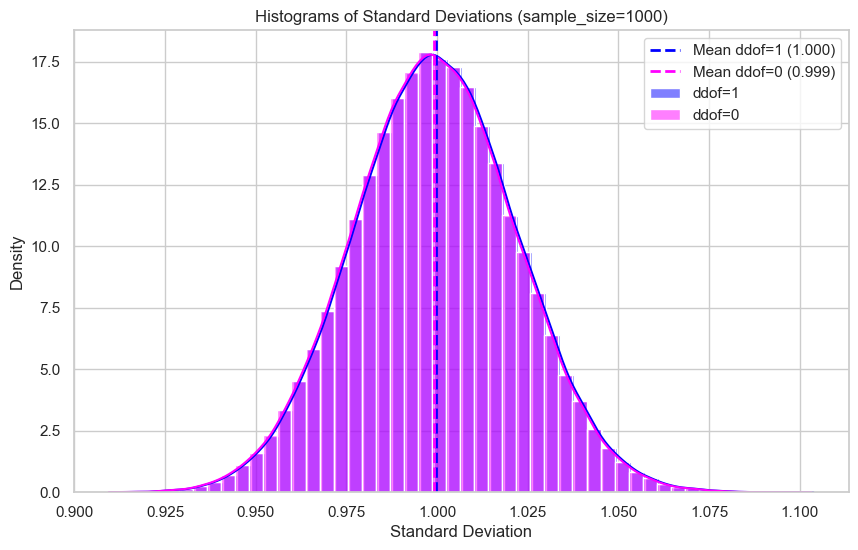

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

number_samples = 100000
sample_size = 1000


samples = np.random.normal(loc=0, scale=1, size=(number_samples, sample_size))

# Calculate SDs
std_ddof1 = np.std(samples, axis=1, ddof=1)  # Sample SD
std_ddof0 = np.std(samples, axis=1, ddof=0)  # Population SD

# Calculate means
mean_ddof1 = np.mean(std_ddof1)
mean_ddof0 = np.mean(std_ddof0)

# Plot histograms
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

sns.histplot(std_ddof1, bins=50, kde=True, stat="density", color='blue', alpha=0.5, label='ddof=1')
sns.histplot(std_ddof0, bins=50, kde=True, stat="density", color='magenta', alpha=0.5, label='ddof=0')

# Mean lines
plt.axvline(mean_ddof1, color='blue', linestyle='--', linewidth=2, label=f'Mean ddof=1 ({mean_ddof1:.3f})')
plt.axvline(mean_ddof0, color='magenta', linestyle='--', linewidth=2, label=f'Mean ddof=0 ({mean_ddof0:.3f})')

plt.xlabel('Standard Deviation')
plt.ylabel('Density')
plt.title('Histograms of Standard Deviations (sample_size=1000)')
plt.legend()
plt.show()


The sample size is increased to 1000. The distributions of both ddof=0 and ddof=1 become more symmetric and their means are closer with a more normal distribution. 